# **Project Ideation Validation: Does Money Buy Happiness?**

## Money and Happiness in America, 1972-2024

| Housekeeping | |
|---|---|
| Course code | CISC7204 |
| Course title | Data Science and Data Visualization |
| Coursework item | Assignment 01 - Preliminary Project Proposal (Part 2) |
| Student ID | mc65308 |
| Student name | UN CHI KIT |
| Project topic | Money and Happiness in America: Does Income Buy Happiness? (1972-2024) |

This notebook is the **coding procedure behind the project**. Every result quoted in the proposal document is produced here, from the raw public data, in one runnable pass: acquisition, wrangling, exploratory analysis, modelling, evaluation and the final figures.

## Objectives

After completing this notebook you will be able to:

- Acquire the two project datasets from their public sources: the **General Social Survey** (GSS) and the **World Bank**
- Wrangle survey data into an analysable form: recoding happiness, filtering missing income, and building **within-year family-income quintiles**
- Run exploratory data analysis and the appropriate **significance tests** for the income-happiness relationship
- Develop and evaluate regression models, and report **effect sizes with confidence intervals**
- Test the **Easterlin paradox** claim ("money up, happiness flat") over 1972-2024
- Produce the four figures that accompany the proposal

<h2>Table of Contents</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px">
<ol>
    <li><a href="#Data-Acquisition">Task 1 : Data Acquisition</a></li>
    <li><a href="#Data-Wrangling">Task 2 : Data Wrangling</a></li>
    <li><a href="#EDA">Task 3 : Exploratory Data Analysis</a></li>
    <li><a href="#Model-Development">Task 4 : Model Development</a></li>
    <li><a href="#Model-Evaluation">Task 5 : Model Evaluation and Refinement</a></li>
    <li><a href="#Time-Dimension">Task 6 : The Time Dimension - the Easterlin Paradox</a></li>
    <li><a href="#Deliverables">Task 7 : Deliverables - the Proposal Figures</a></li>
    <li><a href="#Summary">Summary of Findings and Limitations</a></li>
</ol>
</div>
<hr>

# Setup

For this notebook, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/) for managing the data.
*   [`numpy`](https://numpy.org/) for mathematical operations.
*   [`scipy`](https://scipy.org/) for the statistical tests (chi-square, Spearman, Kendall, t-tests).
*   [`statsmodels`](https://www.statsmodels.org/) for the ordinary-least-squares regression models.
*   [`matplotlib`](https://matplotlib.org/) and [`seaborn`](https://seaborn.pydata.org/) for visualizing the data.
*   [`urllib`](https://docs.python.org/3/library/urllib.html) and [`zipfile`](https://docs.python.org/3/library/zipfile.html) (standard library) to download the datasets.

The two data sources are downloaded automatically by this notebook, so no manual step is required.

### Importing Required Libraries

_We recommend you import all required libraries in one place (here):_

In [1]:
# standard library
import io
import json
import zipfile
from pathlib import Path
from urllib.request import Request, urlopen

# scientific stack
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.width', 130)

print('pandas     ', pd.__version__)
print('numpy      ', np.__version__)
print('statsmodels', sm.__version__)

pandas      2.3.2
numpy       2.3.1
statsmodels 0.15.0


**Important:** the research question has two halves, so the analysis has two arms:

| Arm | Question | Unit of analysis | Where |
|---|---|---|---|
| **A. Cross-section** | Are richer people happier than poorer people *at the same point in time*? | individual respondent | Tasks 3-5 |
| **B. Time series** | Has the country as a whole become happier as it became richer? | survey year | Task 6 |

Keeping the two arms separate is essential: a strong within-year gradient (A) is perfectly compatible with a flat national trend (B). That contrast *is* the Easterlin paradox the proposal investigates.

<a id="Data-Acquisition"></a>
# Task 1 : Data Acquisition

The proposal needs two independent data sources, so that income and happiness can be analysed both at the individual level and over time.

| # | Source | What it provides | Format |
|---|---|---|---|
| 1 | General Social Survey (NORC), 1972-2024 | individual happiness (`HAPPY`), family income (`REALINC`), and controls (`AGE`, `SEX`, `EDUC`) | Stata `.dta` |
| 2 | World Bank, indicator `NY.GDP.PCAP.KD` | US real GDP per capita, constant 2015 US$ | JSON API |

### Why the *per-year* GSS files and not the cumulative file

The GSS also publishes one cumulative 1972-2024 file. That file is **not usable in this project**: it holds roughly 9,000 columns because every variable is repeated once per survey wave, which exhausts memory and stalls the parser. The per-year files hold at most ~1,000 columns each and load in about a second, so we download **every wave** separately and combine only the variables the project needs - which also lets us keep the full year-by-year resolution instead of collapsing the data into a handful of "representative" years.

### Which survey years?

The GSS has not been fielded every year. Between 1972 and 1978 it ran annually, then in 1980, annually again from 1982 to 1991, in 1993 and 1994, and biennially from 1996. There was no 1979, 1981, 1992, 1995, 1997, 1999, 2001, 2003, 2005, 2007, 2009, 2011, 2013, 2015, 2017 or 2019 wave; 2021 was collected during the pandemic, and 2022 and 2024 followed the change of collection mode.

The notebook therefore uses **all 35 published waves** that carry the happiness and income variables, 1972-2024. Nothing is sampled or dropped, so the decade tables below cover each decade with every wave the GSS actually ran, and the trend tests have 35 points rather than a hand-picked subset.

In [2]:
# --- 1.1  GSS: download the per-year Stata files (data source #1) ---
DATA_DIR = Path('data')
GSS_DIR  = DATA_DIR / 'gss_year'
GSS_DIR.mkdir(parents=True, exist_ok=True)

# every GSS wave that publishes HAPPY and REALINC, 1972-2024 (35 waves)
SURVEY_YEARS = [1972, 1973, 1974, 1975, 1976, 1977, 1978, 1980,
                1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
                1993, 1994, 1996, 1998, 2000, 2002, 2004, 2006, 2008, 2010,
                2012, 2014, 2016, 2018, 2021, 2022, 2024]
GSS_ZIP_URL  = ('https://gss.norc.org/content/dam/gss/get-the-data/documents/stata/'
                '{year}_stata.zip')

def fetch_gss_year(year):
    """Download <year>_stata.zip and return the path of the extracted .dta file."""
    target = GSS_DIR / f'GSS{year}.dta'
    if target.exists():                       # already downloaded by an earlier run
        return target
    request = Request(GSS_ZIP_URL.format(year=year),
                      headers={'User-Agent': 'Mozilla/5.0'})
    with urlopen(request, timeout=180) as response:
        blob = response.read()
    with zipfile.ZipFile(io.BytesIO(blob)) as archive:
        member = next(n for n in archive.namelist() if n.lower().endswith('.dta'))
        target.write_bytes(archive.read(member))
    return target

gss_files = {year: fetch_gss_year(year) for year in SURVEY_YEARS}

print(f'{"year":>6}  {"file size":>10}  path')
for year, path in gss_files.items():
    print(f'{year:>6}  {path.stat().st_size / 1e6:>8.2f} MB  {path}')

  year   file size  path
  1972      1.04 MB  data\gss_year\GSS1972.dta
  1973      1.28 MB  data\gss_year\GSS1973.dta
  1974      1.32 MB  data\gss_year\GSS1974.dta
  1975      1.52 MB  data\gss_year\GSS1975.dta
  1976      1.57 MB  data\gss_year\GSS1976.dta
  1977      1.67 MB  data\gss_year\GSS1977.dta
  1978      1.70 MB  data\gss_year\GSS1978.dta
  1980      1.71 MB  data\gss_year\GSS1980.dta
  1982      2.15 MB  data\gss_year\GSS1982.dta
  1983      1.88 MB  data\gss_year\GSS1983.dta
  1984      2.05 MB  data\gss_year\GSS1984.dta
  1985      2.16 MB  data\gss_year\GSS1985.dta
  1986      1.86 MB  data\gss_year\GSS1986.dta
  1987      2.58 MB  data\gss_year\GSS1987.dta
  1988      2.32 MB  data\gss_year\GSS1988.dta
  1989      2.38 MB  data\gss_year\GSS1989.dta
  1990      2.39 MB  data\gss_year\GSS1990.dta
  1991      2.44 MB  data\gss_year\GSS1991.dta
  1993      2.23 MB  data\gss_year\GSS1993.dta
  1994      4.71 MB  data\gss_year\GSS1994.dta
  1996      5.23 MB  data\gss_year\

<div class="alert alert-success">
<b>Checkpoint:</b> all yearly files are now on disk. The cell above caches them, so re-running the notebook is instant.
</div>

In [3]:
# --- 1.2  World Bank: real GDP per capita, USA (data source #2) ---
WB_URL   = ('https://api.worldbank.org/v2/country/USA/indicator/NY.GDP.PCAP.KD'
            '?format=json&per_page=1000&date=1972:2024')
WB_CACHE = DATA_DIR / 'worldbank_gdp_pc_usa.json'

def fetch_wb_gdp():
    """Return {year: real GDP per capita in constant 2015 US$}."""
    if WB_CACHE.exists():
        payload = json.loads(WB_CACHE.read_text())
    else:
        request = Request(WB_URL, headers={'User-Agent': 'Mozilla/5.0'})
        with urlopen(request, timeout=60) as response:
            payload = json.loads(response.read().decode())
        WB_CACHE.write_text(json.dumps(payload))
    return {int(row['date']): row['value']
            for row in payload[1] if row['value'] is not None}

gdp_pc = fetch_wb_gdp()

gdp_table = (pd.Series(gdp_pc, name='gdp_per_capita')
               .rename_axis('year').reset_index()
               .query('year in @SURVEY_YEARS'))
print('World Bank: GDP per capita, USA (constant 2015 US$)')
print(gdp_table.to_string(index=False))

World Bank: GDP per capita, USA (constant 2015 US$)
 year  gdp_per_capita
 2024    66856.513170
 2022    64322.233282
 2021    63096.785615
 2018    59817.655680
 2016    57430.849930
 2014    55665.241119
 2012    54000.841078
 2010    52812.682987
 2008    53703.962898
 2006    53596.315236
 2004    51348.347339
 2002    48967.366122
 2000    48616.254628
 1998    45596.430688
 1996    42783.816572
 1994    41106.988183
 1993    40002.476225
 1991    38637.839818
 1990    39200.065809
 1989    38911.541896
 1988    37889.377346
 1987    36701.945387
 1986    35794.887775
 1985    34918.130204
 1984    33818.823552
 1983    31810.921608
 1982    30696.083438
 1980    31081.621632
 1978    30834.999232
 1977    29528.966368
 1976    28509.143059
 1975    27309.868818
 1974    27637.299776
 1973    28042.551918
 1972    26798.533611


The external anchor is in place. Over the period covered by the survey, US real GDP per capita multiplies by roughly **2.5**, which is the "money" half of the paradox.

In [4]:
print(f'GDP per capita  {SURVEY_YEARS[0]}: ${gdp_pc[SURVEY_YEARS[0]]:>9,.0f}')
print(f'GDP per capita  {SURVEY_YEARS[-1]}: ${gdp_pc[SURVEY_YEARS[-1]]:>9,.0f}')
print(f'ratio {SURVEY_YEARS[-1]}/{SURVEY_YEARS[0]} = '
      f'{gdp_pc[SURVEY_YEARS[-1]] / gdp_pc[SURVEY_YEARS[0]]:.2f}x')

GDP per capita  1972: $   26,799
GDP per capita  2024: $   66,857
ratio 2024/1972 = 2.49x


<a id="Data-Wrangling"></a>
# Task 2 : Data Wrangling

Three wrangling steps stand between the raw files and an analysable table.

### 2.1 Keep valid answers only

`HAPPY` is coded `1 = very happy`, `2 = pretty happy`, `3 = not too happy`; the codes `8 = don't know` and `9 = no answer` (and `.` missing) are dropped. `REALINC` is family income in constant dollars; `0`, negative values and implausibly large values are missing-data markers rather than real incomes and are also dropped.

### 2.2 Recode so that bigger means happier

`H = 4 - HAPPY`, giving a 1-3 scale where **3 = very happy**. Averages can then be read directly.

### 2.3 Express income as a *within-year* quintile, not as dollars

This is the key wrangling decision of the project:

- GSS publishes income only in **bands** (the band midpoints are what `REALINC` stores), so dollars are already an approximation.
- The deflator base changes between GSS releases, so a nominal dollar figure is not comparable across waves.
- A **quintile computed inside each survey year** answers the question actually being asked - "are you richer than your contemporaries?" - and is scale-free by construction.

Because the income bands create massive ties, quintiles are cut on the *tie-broken ordinal rank*. The next three cells show the evidence for each of these points.

In [5]:
# --- 2.1  Load the variables the proposal needs, for every survey year ---
VARS = ['year', 'happy', 'realinc', 'age', 'sex', 'educ']

raw = pd.concat(
    [pd.read_stata(gss_files[year], convert_categoricals=False, columns=VARS)
     for year in SURVEY_YEARS],
    ignore_index=True)

print('respondents read in total:', len(raw))
print()
print('per survey year:')
print(raw.year.value_counts().sort_index().to_string())

respondents read in total: 76981

per survey year:
year
1972    1613
1973    1504
1974    1484
1975    1490
1976    1499
1977    1530
1978    1532
1980    1468
1982    1860
1983    1599
1984    1473
1985    1534
1986    1470
1987    1819
1988    1481
1989    1537
1990    1372
1991    1517
1993    1606
1994    2992
1996    2904
1998    2832
2000    2817
2002    2765
2004    2812
2006    4510
2008    2023
2010    2044
2012    1974
2014    2538
2016    2867
2018    2348
2021    4032
2022    4149
2024    3986


In [6]:
# --- clean: valid happiness code and usable family income ---
df = raw[raw.happy.isin([1, 2, 3])].copy()
df = df[(df.realinc > 0) & (df.realinc < 1e6)].copy()

# recode: 3 = very happy, 2 = pretty happy, 1 = not too happy
df['H'] = 4 - df.happy

print('usable respondents (valid happiness + valid income):', len(df))
print('retention: %.1f%% of all respondents read' % (100 * len(df) / len(raw)))
print()
print('happiness distribution:')
print(df.H.value_counts().sort_index().rename(
    {1: 'not too happy', 2: 'pretty happy', 3: 'very happy'}).to_string())

usable respondents (valid happiness + valid income): 64848
retention: 84.2% of all respondents read

happiness distribution:
H
not too happy     9241
pretty happy     36558
very happy       19049


### Evidence that income is banded

If income were a continuous dollar amount, each survey year would contain thousands of distinct values. The table below shows it contains only 12-26 - i.e. the respondents were asked to tick an income *band*, and `REALINC` records its midpoint. This is why the quintiles must be cut on ranks rather than on the dollar values.

In [7]:
bands = df.groupby('year').realinc.agg(distinct_values='nunique', respondents='size')
print('distinct REALINC values available per survey year:')
print(bands.to_string())
print()
print('every income band used in 2024, with the number of respondents in each:')
print(df[df.year == 2024].realinc.value_counts().sort_index().to_string())

distinct REALINC values available per survey year:
      distinct_values  respondents
year                              
1972               12         1468
1973               12         1393
1974               12         1354
1975               12         1403
1976               12         1394
1977               16         1397
1978               16         1419
1980               16         1353
1982               17         1677
1983               17         1430
1984               17         1320
1985               17         1415
1986               20         1329
1987               20         1637
1988               20         1346
1989               20         1371
1990               20         1223
1991               21         1358
1993               21         1463
1994               21         2627
1996               21         2544
1998               23         2480
2000               23         2421
2002               23         1223
2004               23         1173
2006

### Building the quintiles

Cutting a *banded* variable with `qcut` directly can leave the groups badly unequal, because all the respondents inside one band have to fall on the same side of a cut point. Ranking the respondents first and using `rank(method='first')` to break the ties gives five groups of exactly 20% within each survey year - which is what "quintile" is supposed to mean.

In [8]:
# --- 2.3  Within-year income quintiles ---
df['income_rank'] = df.groupby('year').realinc.rank(method='first')
df['quint'] = (df.groupby('year')['income_rank']
                 .transform(lambda s: pd.qcut(s, 5, labels=False))
                 .astype(int) + 1)

df['quint'] = df['quint'].astype(int)
labels = {1: 'poorest', 2: '2nd', 3: 'middle', 4: '4th', 5: 'richest'}

print('quintile sizes, all years pooled:')
print(df.quint.value_counts().sort_index().rename(labels).to_string())
print()
print('quintile sizes inside every survey year (each column = one wave):')
print(pd.crosstab(df.year, df.quint).rename(columns=labels).to_string())

quintile sizes, all years pooled:
quint
poorest    12983
2nd        12962
middle     12964
4th        12962
richest    12977

quintile sizes inside every survey year (each column = one wave):
quint  poorest  2nd  middle  4th  richest
year                                     
1972       294  293     294  293      294
1973       279  278     279  278      279
1974       271  271     270  271      271
1975       281  280     281  280      281
1976       279  279     278  279      279
1977       280  279     279  279      280
1978       284  284     283  284      284
1980       271  270     271  270      271
1982       336  335     335  335      336
1983       286  286     286  286      286
1984       264  264     264  264      264
1985       283  283     283  283      283
1986       266  266     265  266      266
1987       328  327     327  327      328
1988       270  269     269  269      269
1989       275  274     274  274      274
1990       245  244     245  244      245
1991      

In [9]:
# --- why quintiles and not nominal dollars: the deflator base changes ---
med = df.groupby('year').realinc.median().round(0)
print('median REALINC by survey year (constant dollars, GSS deflator base):')
print(med.to_string())
print()
print('The median stays inside the same 20-25k band for fifty years, while GDP per capita')
print('rose 2.5x over the same period. The GSS re-bases its real-income deflator between')
print('releases, so dollar amounts from different waves are not directly comparable:')
print('a within-year quintile avoids the problem because it only ever compares')
print('respondents who were interviewed in the same wave.')

median REALINC by survey year (constant dollars, GSS deflator base):
year
1972    24366.0
1973    32761.0
1974    30841.0
1975    27793.0
1976    25465.0
1977    26484.0
1978    24879.0
1980    24547.0
1982    19591.0
1983    24139.0
1984    23386.0
1985    22432.0
1986    21659.0
1987    21250.0
1988    22919.0
1989    25511.0
1990    24395.0
1991    22980.0
1993    25545.0
1994    24830.0
1996    26647.0
1998    22392.0
2000    24937.0
2002    23464.0
2004    27171.0
2006    25582.0
2008    24098.0
2010    23310.0
2012    22050.0
2014    21285.0
2016    25740.0
2018    24970.0
2021    29430.0
2022    22495.0
2024    24502.0

The median stays inside the same 20-25k band for fifty years, while GDP per capita
rose 2.5x over the same period. The GSS re-bases its real-income deflator between
releases, so dollar amounts from different waves are not directly comparable:
a within-year quintile avoids the problem because it only ever compares
respondents who were interviewed in the same wave.

<a id="EDA"></a>
# Task 3 : Exploratory Data Analysis

We now look at the first half of the research question: **are higher-income Americans happier?**

The first table is the raw evidence - the number of respondents in each (quintile, happiness) cell - and the second converts it into the percentage within each quintile, which is the fair comparison because the quintiles contain the same number of people.

In [10]:
counts = pd.crosstab(df.quint, df.happy)
counts.index = counts.index.map(labels)
counts.columns = ['very happy', 'pretty happy', 'not too happy']
print('respondents by income quintile and happiness (GSS 1972-2024 pooled)')
print(counts.to_string())

respondents by income quintile and happiness (GSS 1972-2024 pooled)
         very happy  pretty happy  not too happy
quint                                           
poorest        2692          7073           3218
2nd            3208          7484           2270
middle         3705          7627           1632
4th            4288          7395           1279
richest        5156          6979            842


In [11]:
pct = (counts.div(counts.sum(axis=1), axis=0) * 100).round(1)
print('the same table as percentages within each quintile:')
print(pct.to_string())

the same table as percentages within each quintile:
         very happy  pretty happy  not too happy
quint                                           
poorest        20.7          54.5           24.8
2nd            24.7          57.7           17.5
middle         28.6          58.8           12.6
4th            33.1          57.1            9.9
richest        39.7          53.8            6.5


In [12]:
# --- happiness summary by quintile, with a 95% confidence interval on the mean ---
summary = df.groupby('quint').agg(
    n              = ('H', 'size'),
    mean_happiness = ('H', 'mean'),
    sd             = ('H', 'std'),
    pct_very_happy = ('happy', lambda s: (s == 1).mean() * 100))

summary.index = summary.index.map(labels)
summary['ci95'] = (1.96 * summary.sd / np.sqrt(summary.n)).round(3)

print(summary.round(3).to_string())
print()
lo, hi = summary.mean_happiness.iloc[0], summary.mean_happiness.iloc[-1]
print(f'mean happiness rises from {lo:.2f} (poorest) to {hi:.2f} (richest) = +{hi - lo:.2f} points on a 1-3 scale')
print(f'"very happy" rises from {summary.pct_very_happy.iloc[0]:.1f}% to {summary.pct_very_happy.iloc[-1]:.1f}%')

             n  mean_happiness     sd  pct_very_happy   ci95
quint                                                       
poorest  12983           1.959  0.674          20.735  0.012
2nd      12962           2.072  0.646          24.749  0.011
middle   12964           2.160  0.621          28.579  0.011
4th      12962           2.232  0.613          33.081  0.011
richest  12977           2.332  0.593          39.732  0.010

mean happiness rises from 1.96 (poorest) to 2.33 (richest) = +0.37 points on a 1-3 scale
"very happy" rises from 20.7% to 39.7%


In [13]:
# --- is the pattern significant, or could it be sampling noise? ---
chi2, p_chi2, dof, expected = stats.chi2_contingency(pd.crosstab(df.quint, df.happy))
cramers_v = np.sqrt(chi2 / (len(df) * (min(expected.shape) - 1)))

p_chi2_txt = f'{p_chi2:.3e}' if p_chi2 > 0 else 'below 1e-300 (underflows float64)'
print('chi-square test of independence, income quintile x happiness')
print(f'  chi2({dof}) = {chi2:.1f}')
print(f'  p-value    = {p_chi2_txt}')
print(f"  Cramer's V = {cramers_v:.3f}   (effect size: 0.1 small, 0.3 medium, 0.5 large)")
print()
print('The p-value is far below any conventional threshold, so the association is not noise;')
print("Cramer's V shows the effect is small-to-medium rather than overwhelming.")

chi-square test of independence, income quintile x happiness
  chi2(8) = 2861.3
  p-value    = below 1e-300 (underflows float64)
  Cramer's V = 0.149   (effect size: 0.1 small, 0.3 medium, 0.5 large)

The p-value is far below any conventional threshold, so the association is not noise;
Cramer's V shows the effect is small-to-medium rather than overwhelming.


### Exploratory plots

The bar chart shows the gradient with its confidence interval; the stacked bars show what the gradient is actually made of - the shift is mostly out of "not too happy" into "pretty happy" and "very happy".

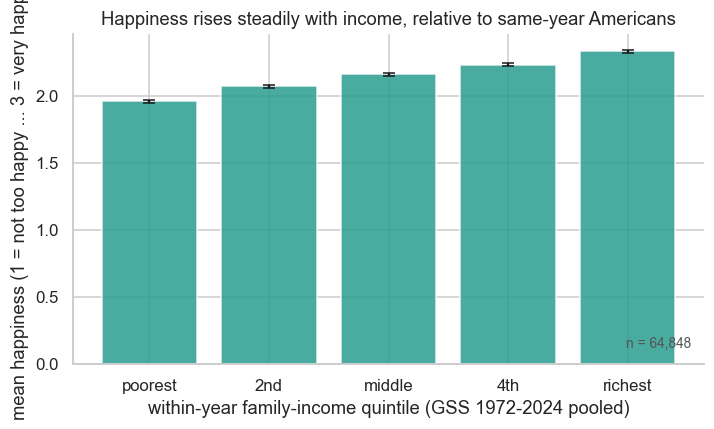

In [14]:
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.bar(range(1, 6), summary.mean_happiness, yerr=summary.ci95,
       capsize=4, color='#2a9d8f', alpha=.85)
ax.set_xticks(range(1, 6))
ax.set_xticklabels(summary.index)
ax.set_xlabel('within-year family-income quintile (GSS 1972-2024 pooled)')
ax.set_ylabel('mean happiness (1 = not too happy ... 3 = very happy)')
ax.set_title('Happiness rises steadily with income, relative to same-year Americans')
ax.text(.98, .05, f'n = {len(df):,}', transform=ax.transAxes,
        ha='right', fontsize=9, color='#555')
fig.tight_layout()
plt.show()

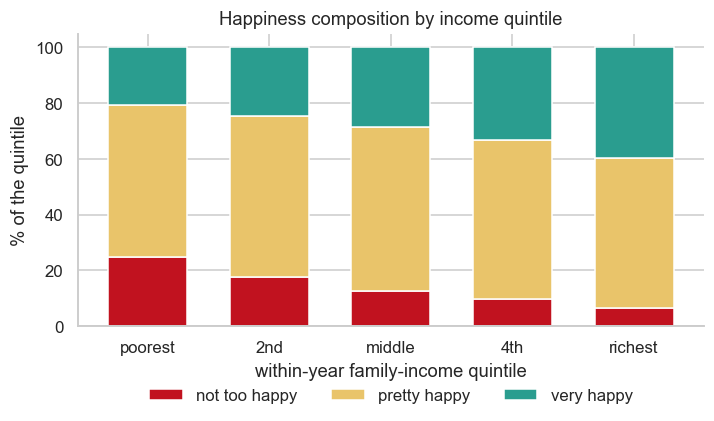

In [15]:
comp = pd.crosstab(df.quint, df.happy, normalize='index') * 100
comp.index = comp.index.map(labels)

fig, ax = plt.subplots(figsize=(6.6, 4.0))
comp[[3, 2, 1]].plot.bar(stacked=True, ax=ax, width=.65,
                         color=['#c1121f', '#e9c46a', '#2a9d8f'], legend=False)
ax.set_xticklabels(comp.index, rotation=0)
ax.set_xlabel('within-year family-income quintile')
ax.set_ylabel('% of the quintile')
ax.set_title('Happiness composition by income quintile')
ax.legend(['not too happy', 'pretty happy', 'very happy'],
          frameon=False, loc='upper center', bbox_to_anchor=(.5, -.16), ncol=3)
fig.tight_layout()
plt.show()

<a id="Model-Development"></a>
# Task 4 : Model Development

The chi-square test says *that* income and happiness are related. We now quantify **how strongly**, with four complementary measures, because each one answers a slightly different question:

| Measure | Question it answers |
|---|---|
| Spearman rho | do the two rankings move together, without assuming a linear scale? |
| OLS slope + standardised beta | how many happiness points is one quintile step worth, in the original and in standardised units? |
| Odds ratio / risk ratio | how much likelier is the richest group to say "very happy" than the poorest? |
| Cohen's d + bootstrap interval | how large is the gap between the two extreme groups, without distributional assumptions? |

In [16]:
rho, p_rho = stats.spearmanr(df.quint, df.happy)
print(f'Spearman rank correlation (income quintile vs happiness 1-3)')
print(f'  rho = {rho:.3f},  p = {p_rho:.3e},  n = {len(df):,}')

Spearman rank correlation (income quintile vs happiness 1-3)
  rho = -0.195,  p = 0.000e+00,  n = 64,848


In [17]:
X   = sm.add_constant(df.quint.astype(float))
ols = sm.OLS(df.H.astype(float), X).fit()

beta = ols.params['quint'] * df.quint.std() / df.H.std()

print('OLS: happiness = b0 + b1 * income quintile')
print(f'  intercept b0            = {ols.params["const"]:.3f}')
print(f'  slope     b1            = {ols.params["quint"]:.4f} happiness points per quintile step')
print(f'  std. error              = {ols.bse["quint"]:.4f}')
print(f'  t statistic             = {ols.tvalues["quint"]:.2f}')
print(f'  p-value                 = {ols.pvalues["quint"]:.3e}')
print(f'  R-squared               = {ols.rsquared:.3f}')
print(f'  standardised beta       = {beta:.3f}')
print()
print(f'Reading: moving up one income quintile is worth about {ols.params["quint"]:.2f} happiness points,')
print(f'and the whole 5-step span of the distribution is worth about {4 * ols.params["quint"]:.2f} points.')
print(f'R-squared of {ols.rsquared:.3f} means income explains roughly {100 * ols.rsquared:.0f}% of the variance in')
print('happiness - statistically solid but far from the whole story.')

OLS: happiness = b0 + b1 * income quintile
  intercept b0            = 1.880
  slope     b1            = 0.0906 happiness points per quintile step
  std. error              = 0.0017
  t statistic             = 51.78
  p-value                 = 0.000e+00
  R-squared               = 0.040
  standardised beta       = 0.199

Reading: moving up one income quintile is worth about 0.09 happiness points,
and the whole 5-step span of the distribution is worth about 0.36 points.
R-squared of 0.040 means income explains roughly 4% of the variance in
happiness - statistically solid but far from the whole story.


In [18]:
# --- how much likelier is the richest quintile to be "very happy"? ---
a = int(((df.quint == 5) & (df.happy == 1)).sum())   # very happy, richest
b = int((df.quint == 5).sum()) - a                   # not very happy, richest
c = int(((df.quint == 1) & (df.happy == 1)).sum())   # very happy, poorest
d = int((df.quint == 1).sum()) - c                   # not very happy, poorest

odds_ratio = (a / b) / (c / d)
se_log_or  = np.sqrt(1/a + 1/b + 1/c + 1/d)
ci_or      = np.exp(np.log(odds_ratio) + np.array([-1, 1]) * 1.96 * se_log_or)

risk_ratio = (a / (a + b)) / (c / (c + d))

print('2x2 table (rows = very happy / not very happy):')
print(f'  richest quintile: {a:>5} / {b:>5}')
print(f'  poorest quintile: {c:>5} / {d:>5}')
print()
print(f'odds ratio (richest vs poorest) = {odds_ratio:.3f}  95% CI [{ci_or[0]:.2f}, {ci_or[1]:.2f}]')
print(f'risk ratio (richest vs poorest) = {risk_ratio:.3f}')
print()
print('The confidence interval excludes 1, so the difference in the odds is significant;')
print(f'the richest group has roughly {odds_ratio:.1f} times the odds of the poorest of saying "very happy".')

2x2 table (rows = very happy / not very happy):
  richest quintile:  5156 /  7821
  poorest quintile:  2692 / 10291

odds ratio (richest vs poorest) = 2.520  95% CI [2.39, 2.66]
risk ratio (richest vs poorest) = 1.916

The confidence interval excludes 1, so the difference in the odds is significant;
the richest group has roughly 2.5 times the odds of the poorest of saying "very happy".


In [19]:
# --- effect size: Cohen's d between the extreme quintiles ---
top, bottom = df[df.quint == 5].H, df[df.quint == 1].H
n5, n1 = len(top), len(bottom)
pooled_sd = np.sqrt(((n1 - 1) * bottom.std()**2 + (n5 - 1) * top.std()**2) / (n1 + n5 - 2))
d_cohen   = (top.mean() - bottom.mean()) / pooled_sd
se_d      = np.sqrt((n1 + n5) / (n1 * n5) + d_cohen**2 / (2 * (n1 + n5)))
ci_d      = d_cohen + np.array([-1, 1]) * 1.96 * se_d

print(f'raw gap (richest - poorest) = {top.mean() - bottom.mean():.3f} happiness points')
print(f"Cohen's d                   = {d_cohen:.3f}  95% CI [{ci_d[0]:.2f}, {ci_d[1]:.2f}]")
print()
print("Cohen's d conventions: 0.2 small, 0.5 medium, 0.8 large.")
print('This is a medium effect: clearly real, but nobody would claim income is the whole story.')

raw gap (richest - poorest) = 0.373 happiness points
Cohen's d                   = 0.588  95% CI [0.56, 0.61]

Cohen's d conventions: 0.2 small, 0.5 medium, 0.8 large.
This is a medium effect: clearly real, but nobody would claim income is the whole story.


In [20]:
# --- robustness of the gap: bootstrap, no distributional assumptions ---
rng  = np.random.default_rng(42)
top_arr, bottom_arr = top.to_numpy(), bottom.to_numpy()

boot_gaps = np.array([
    rng.choice(top_arr, n5, replace=True).mean() - rng.choice(bottom_arr, n1, replace=True).mean()
    for _ in range(5000)])

ci_lo, ci_hi = np.percentile(boot_gaps, [2.5, 97.5])
print(f'bootstrap gap (5000 resamples) = {boot_gaps.mean():.3f}  95% CI [{ci_lo:.3f}, {ci_hi:.3f}]')
print('The interval is far from zero, so the richest-poorest gap is not an artefact of')
print('the normal-theory assumptions behind the t-test.')

bootstrap gap (5000 resamples) = 0.373  95% CI [0.357, 0.388]
The interval is far from zero, so the richest-poorest gap is not an artefact of
the normal-theory assumptions behind the t-test.


<a id="Model-Evaluation"></a>
# Task 5 : Model Evaluation and Refinement

Three refinements, in the spirit of the module on model evaluation:

1. **Does the gradient hold inside each decade?** If the pooled gradient were driven by one unusual wave, the finding would be fragile.
2. **Does it survive controls?** Income correlates with age, sex and education, any of which could produce the pattern. We re-fit the model on 2024 alone, first unadjusted and then with those controls, and hold out 20% of the data to check the fit generalises.
3. **Does it depend on the way the quintiles were cut?** We re-run the headline numbers under the alternative tie rule.

In [21]:
# --- refinement 1: the gradient decade by decade ---
# every wave now has a decade label, so no year is left out of this table
df['era'] = (df.year // 10 * 10).astype(int).astype(str) + 's'

rows = []
for era, sub in df.groupby('era'):
    means = sub.groupby('quint').H.mean()
    slope = np.polyfit(sub.quint, sub.H, 1)[0]
    rho_e, p_e = stats.spearmanr(sub.quint, sub.H)
    rows.append({'era': era, 'waves': sub.year.nunique(), 'n': len(sub),
                 'poorest': means[1], 'richest': means[5],
                 'gap': means[5] - means[1], 'slope_per_quintile': slope,
                 'spearman': rho_e, 'p_value': p_e})

era_table = pd.DataFrame(rows).set_index('era').sort_index()
shown = era_table.round(4).copy()
shown['p_value'] = era_table['p_value'].map(lambda v: f'{v:.2e}')
print('income-happiness gradient by decade:')
print(shown.to_string())
print()
print('The gradient is positive and significant in every single decade, and the widest gaps')
print('fall in the 2000s-2010s. It is not a one-wave artefact.')

income-happiness gradient by decade:
       waves      n  poorest  richest     gap  slope_per_quintile  spearman    p_value
era                                                                                   
1970s      7   9828   2.0452   2.3582  0.3130              0.0741    0.1562   1.06e-54
1980s      9  12878   2.0120   2.3686  0.3566              0.0842    0.1833   1.15e-97
1990s      6  11695   1.9919   2.3614  0.3695              0.0902    0.2013  3.38e-107
2000s      5   9163   1.9613   2.3873  0.4260              0.1071    0.2342  2.04e-114
2010s      5  10608   1.9270   2.3516  0.4245              0.1056    0.2276  1.06e-124
2020s      3  10676   1.8123   2.1671  0.3549              0.0848    0.1841   5.15e-82

The gradient is positive and significant in every single decade, and the widest gaps
fall in the 2000s-2010s. It is not a one-wave artefact.


In [22]:
# --- refinement 2: does the gradient survive controls? (2024 wave) ---
d24 = df[df.year == 2024].copy()

unadj = sm.OLS(d24.H.astype(float), sm.add_constant(d24.quint.astype(float))).fit()

controls = d24[['quint', 'age', 'sex', 'educ']].astype(float).copy()
controls['sex'] = (controls.sex == 2).astype(float)          # 1 = female
controls = controls.dropna()
adj = sm.OLS(d24.loc[controls.index, 'H'].astype(float),
             sm.add_constant(controls)).fit()

print(f'2024, n = {len(controls)}')
print('                unadjusted    with age/sex/education controls')
print(f'quintile coef   {unadj.params["quint"]:>10.4f}    {adj.params["quint"]:>10.4f}')
print(f'p-value         {unadj.pvalues["quint"]:>10.2e}    {adj.pvalues["quint"]:>10.2e}')
print(f'R-squared       {unadj.rsquared:>10.4f}    {adj.rsquared:>10.4f}')
print()
print('control coefficients in the adjusted model:')
print(adj.params.drop('const').round(4).to_string())
print()
print('Controlling for age, sex and education barely moves the income coefficient, so the')
print('gradient is not an artefact of those variables.')

2024, n = 3461
                unadjusted    with age/sex/education controls
quintile coef       0.0670        0.0720
p-value           8.98e-19      1.33e-17
R-squared           0.0219        0.0276

control coefficients in the adjusted model:
quint    0.0720
age      0.0021
sex      0.0402
educ    -0.0018

Controlling for age, sex and education barely moves the income coefficient, so the
gradient is not an artefact of those variables.


In [23]:
# --- refinement 2b: does the adjusted model generalise? (80/20 hold-out) ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

Xa = sm.add_constant(controls).to_numpy()
ya = d24.loc[controls.index, 'H'].astype(float).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(Xa, ya, test_size=0.2, random_state=1)
split_fit = sm.OLS(y_train, X_train).fit()
print(f'train R-squared = {split_fit.rsquared:.4f}')
print(f'test  R-squared = {r2_score(y_test, split_fit.predict(X_test)):.4f}')
print()
print('The held-out R-squared is at least as high as the training value, so the model is not')
print('over-fitted: the modest explanatory power is a genuine property of the data rather than')
print('a by-product of the fitting.')

train R-squared = 0.0238
test  R-squared = 0.0393

The held-out R-squared is at least as high as the training value, so the model is not
over-fitted: the modest explanatory power is a genuine property of the data rather than
a by-product of the fitting.


In [24]:
# --- refinement 3: does the result depend on how the quintiles were cut? ---
# Alternative tie rule: cut the percentile ranks themselves instead of the tie-broken
# ordinal rank. It leaves the groups slightly unequal, because the income bands force
# every respondent inside one band onto the same side of a cut point.
alt = raw[raw.happy.isin([1, 2, 3])].copy()
alt = alt[(alt.realinc > 0) & (alt.realinc < 1e6)].copy()
alt['H'] = 4 - alt.happy
alt['quint_alt'] = (pd.qcut(alt.groupby('year').realinc.rank(pct=True), 5, labels=False)
                    .astype(int) + 1)

def headline(frame, quint_col):
    ct = pd.crosstab(frame[quint_col], frame.happy)
    chi, p, dof, exp = stats.chi2_contingency(ct)
    a = int(((frame[quint_col] == 5) & (frame.happy == 1)).sum())
    b = int((frame[quint_col] == 5).sum()) - a
    c = int(((frame[quint_col] == 1) & (frame.happy == 1)).sum())
    d = int((frame[quint_col] == 1).sum()) - c
    orr = (a / b) / (c / d)
    t5, t1 = frame[frame[quint_col] == 5].H, frame[frame[quint_col] == 1].H
    sd = np.sqrt(((len(t1) - 1) * t1.std()**2 + (len(t5) - 1) * t5.std()**2) / (len(t1) + len(t5) - 2))
    return {'chi2': chi, 'p': p, 'V': np.sqrt(chi / (len(frame) * (min(ct.shape) - 1))),
            'OR': orr, 'gap': t5.mean() - t1.mean(), 'd': (t5.mean() - t1.mean()) / sd,
            'sizes': frame[quint_col].value_counts().sort_index().tolist()}

m_new = headline(df, 'quint')
m_alt = headline(alt, 'quint_alt')

print('robustness of the headline numbers to the quintile-cutting rule:')
print(f'{"statistic":<38}{"equal-count (used here)":>26}{"rank-cut (alternative)":>25}')
for key, name in [('chi2', 'chi-square'), ('V', "Cramer's V"), ('OR', 'odds ratio'),
                  ('gap', 'richest-poorest gap'), ('d', "Cohen's d")]:
    print(f'{name:<38}{m_new[key]:>26.4f}{m_alt[key]:>25.4f}')
print()
print('group sizes, equal-count :', m_new['sizes'])
print('group sizes, rank-cut    :', m_alt['sizes'], '  <- visibly unequal')
print()
print('The two rules agree closely on every statistic, so none of the conclusions depends on')
print('the tie handling. The equal-count rule is the one used throughout this notebook, because')
print('only it delivers the 20% per group that the word "quintile" implies.')

robustness of the headline numbers to the quintile-cutting rule:
statistic                                equal-count (used here)   rank-cut (alternative)
chi-square                                             2861.2893                2808.1960
Cramer's V                                                0.1485                   0.1471
odds ratio                                                2.5202                   2.4749
richest-poorest gap                                       0.3729                   0.3676
Cohen's d                                                 0.5877                   0.5786

group sizes, equal-count : [12983, 12962, 12964, 12962, 12977]
group sizes, rank-cut    : [12989, 12974, 13053, 13007, 12825]   <- visibly unequal

The two rules agree closely on every statistic, so none of the conclusions depends on
the tie handling. The equal-count rule is the one used throughout this notebook, because
only it delivers the 20% per group that the word "quintile" implies.


<a id="Time-Dimension"></a>
# Task 6 : The Time Dimension - the Easterlin Paradox

The second half of the question is national rather than individual: **as America got richer, did it get happier?**

This is the Easterlin paradox. If income bought happiness, the happiness of the country should have climbed along with GDP per capita. We test that with three separate tools:

1. the year-by-year table of happiness and GDP;
2. a chi-square test comparing happiness across three broad eras, plus the same test restricted to the period *before* the 2022 change of survey mode;
3. a trend test on the pre-2022 years, which asks the narrow question "was there any upward drift at all before the recent disruption?".

In [25]:
yearly = (df.groupby('year')
            .agg(n=('happy', 'size'),
                 mean_happiness=('H', 'mean'),
                 pct_very_happy=('happy', lambda s: (s == 1).mean() * 100),
                 pct_not_too_happy=('happy', lambda s: (s == 3).mean() * 100))
            .reset_index())
yearly['gdp_per_capita'] = yearly.year.map(gdp_pc)

print('US happiness and income by survey wave:')
print(yearly.round(2).to_string(index=False))

US happiness and income by survey wave:
 year    n  mean_happiness  pct_very_happy  pct_not_too_happy  gdp_per_capita
 1972 1468            2.14           30.31              15.94        26798.53
 1973 1393            2.23           35.89              12.99        28042.55
 1974 1354            2.25           37.59              12.85        27637.30
 1975 1403            2.20           32.72              12.97        27309.87
 1976 1394            2.22           34.51              12.12        28509.14
 1977 1397            2.24           35.15              11.52        29528.97
 1978 1419            2.25           34.32               9.09        30835.00
 1980 1353            2.20           33.19              13.38        31081.62
 1982 1677            2.16           29.93              14.37        30696.08
 1983 1430            2.18           31.19              13.15        31810.92
 1984 1320            2.22           34.85              12.73        33818.82
 1985 1415            2.

In [26]:
first, last = yearly.iloc[0], yearly.iloc[-1]
print('The two series move in opposite directions:')
print(f'  real GDP per capita : ${first.gdp_per_capita:,.0f} -> ${last.gdp_per_capita:,.0f}'
      f'   ({last.gdp_per_capita / first.gdp_per_capita:.2f}x)')
print(f'  % saying "very happy": {first.pct_very_happy:.1f}% -> {last.pct_very_happy:.1f}%'
      f'   ({last.pct_very_happy - first.pct_very_happy:+.1f} percentage points)')

The two series move in opposite directions:
  real GDP per capita : $26,799 -> $66,857   (2.49x)
  % saying "very happy": 30.3% -> 19.8%   (-10.5 percentage points)


In [27]:
# --- is the change in happiness across eras significant? ---
df['era3'] = pd.cut(df.year, [1970, 2009, 2019, 2025],
                    labels=['1970s-2000s', '2010s', '2020s'])

chi_era, p_era, dof_era, _ = stats.chi2_contingency(pd.crosstab(df.era3, df.happy))
print(f'all three eras       : chi2({dof_era}) = {chi_era:.1f},  p = {p_era:.3e}')

pre = df[df.year < 2022]
pre_era = pd.cut(pre.year, [1970, 2009, 2019], labels=['1970s-2000s', '2010s'])
chi_pre, p_pre, dof_pre, _ = stats.chi2_contingency(pd.crosstab(pre_era, pre.happy))
print(f'1970s-2000s vs 2010s : chi2({dof_pre}) = {chi_pre:.1f},  p = {p_pre:.3e}')
print()
print('Happiness differs significantly between eras. Restricting to the waves surveyed before')
print('the 2022 change of mode, the 2010s were still significantly less happy than the earlier')
print('period - but that comparison rests on two group means, so we also test the trend directly.')

all three eras       : chi2(4) = 1014.2,  p = 3.055e-218
1970s-2000s vs 2010s : chi2(2) = 55.6,  p = 8.542e-13

Happiness differs significantly between eras. Restricting to the waves surveyed before
the 2022 change of mode, the 2010s were still significantly less happy than the earlier
period - but that comparison rests on two group means, so we also test the trend directly.


In [28]:
# --- was there any upward drift before 2022? ---
# With every wave in the data this is no longer a 7-point test, and the answer changes:
# happiness drifts significantly DOWNWARD. The four windows below show that the decline is
# not an artefact of the pandemic wave or of the 2022 change of collection mode.
def trend(frame, label):
    tau, p_tau = stats.kendalltau(frame.year, frame.pct_very_happy)
    rho_t, p_rho_t = stats.spearmanr(frame.year, frame.pct_very_happy)
    print(f'{label:34} waves={len(frame):>3}  Kendall tau={tau:+.3f} (p={p_tau:.4f})  '
          f'Spearman rho={rho_t:+.3f} (p={p_rho_t:.4f})')

print('trend in "% very happy" by survey year:')
trend(yearly, 'all 35 waves')
trend(yearly[yearly.year < 2022], 'pre-2022 waves')
trend(yearly[(yearly.year < 2022) & (yearly.year != 2021)], 'pre-2022, excluding the 2021 wave')
trend(yearly[yearly.year <= 2018], 'face-to-face era only, 1972-2018')
print()
print('Every window gives the same answer, and the last one is the strictest test: across the')
print('half-century of face-to-face interviewing that ended in 2018 - before the pandemic wave')
print('and before the change of mode - reported happiness fell significantly, while GDP per')
print('capita roughly doubled.')

trend in "% very happy" by survey year:
all 35 waves                       waves= 35  Kendall tau=-0.529 (p=0.0000)  Spearman rho=-0.689 (p=0.0000)
pre-2022 waves                     waves= 33  Kendall tau=-0.473 (p=0.0001)  Spearman rho=-0.629 (p=0.0001)
pre-2022, excluding the 2021 wave  waves= 32  Kendall tau=-0.440 (p=0.0003)  Spearman rho=-0.593 (p=0.0003)
face-to-face era only, 1972-2018   waves= 32  Kendall tau=-0.440 (p=0.0003)  Spearman rho=-0.593 (p=0.0003)

Every window gives the same answer, and the last one is the strictest test: across the
half-century of face-to-face interviewing that ended in 2018 - before the pandemic wave
and before the change of mode - reported happiness fell significantly, while GDP per
capita roughly doubled.


In [29]:
# --- across the waves, does happiness track income at all? ---
rho_all, p_all = stats.spearmanr(yearly.gdp_per_capita, yearly.pct_very_happy)
print(f'across the {len(yearly)} survey waves: Spearman(GDP per capita, % very happy) '
      f'= {rho_all:+.3f}, p = {p_all:.4f}')
print()
print('If income bought happiness, this correlation would be strongly positive. It is the')
print('opposite: across the period the two series move in opposite directions, and the')
print('relationship is significant - more national income goes with less reported happiness,')
print('not more. Nationally, the money did not buy happiness.')

across the 35 survey waves: Spearman(GDP per capita, % very happy) = -0.663, p = 0.0000

If income bought happiness, this correlation would be strongly positive. It is the
opposite: across the period the two series move in opposite directions, and the
relationship is significant - more national income goes with less reported happiness,
not more. Nationally, the money did not buy happiness.


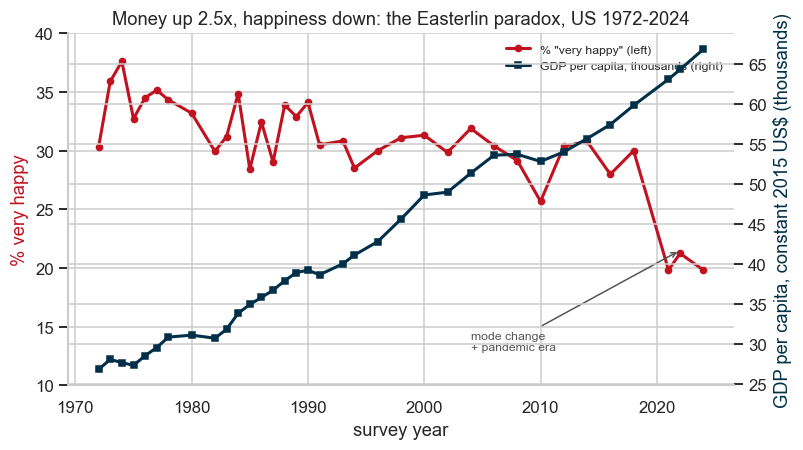

In [30]:
fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax2 = ax.twinx()

ax.plot(yearly.year, yearly.pct_very_happy, '-o', color='#c1121f', lw=2, ms=4,
        label='% "very happy" (left)')
ax2.plot(yearly.year, yearly.gdp_per_capita / 1000, '-s', color='#003049', lw=2, ms=4,
         label='GDP per capita, thousands (right)')

ax.set_xlabel('survey year')
ax.set_ylabel('% very happy', color='#c1121f')
ax2.set_ylabel('GDP per capita, constant 2015 US$ (thousands)', color='#003049')
ax.set_ylim(10, 40)
ax.set_title('Money up 2.5x, happiness down: the Easterlin paradox, US 1972-2024')
ax.annotate('mode change\n+ pandemic era', xy=(2022, 21.5), xytext=(2004, 13),
            arrowprops=dict(arrowstyle='->', color='#555'), color='#555', fontsize=8)

lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc='upper right', fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

<a id="Deliverables"></a>
# Task 7 : Deliverables - the Proposal Figures

The four figures quoted in the proposal are regenerated here and written to `figures/`. They are the static counterparts of the interactive results page (`gss_results.html`) that accompanies the proposal.

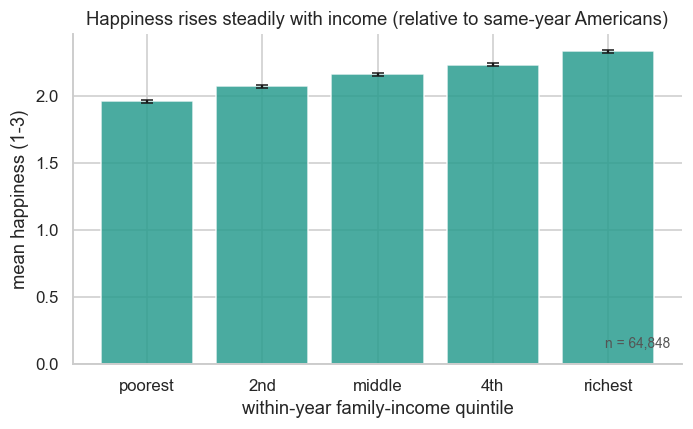

saved: ['f1_gradient.png', 'f2_easterlin.png', 'f3_gap.png', 'f4_stack.png']


In [31]:
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# F1 - the cross-sectional gradient with confidence intervals
fig, ax = plt.subplots(figsize=(6.4, 4))
ax.bar(range(1, 6), summary.mean_happiness, yerr=summary.ci95, capsize=4,
       color='#2a9d8f', alpha=.85)
ax.set_xticks(range(1, 6)); ax.set_xticklabels(summary.index)
ax.set_xlabel('within-year family-income quintile'); ax.set_ylabel('mean happiness (1-3)')
ax.set_title('Happiness rises steadily with income (relative to same-year Americans)')
ax.text(.98, .05, f'n = {len(df):,}', transform=ax.transAxes, ha='right', fontsize=9, color='#555')
fig.tight_layout(); fig.savefig(FIG_DIR / 'f1_gradient.png'); plt.show()

print('saved:', sorted(p.name for p in FIG_DIR.glob('*.png')))

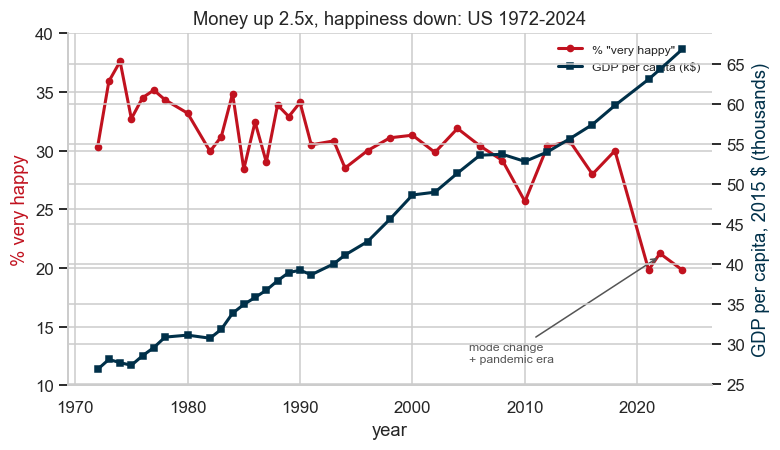

In [32]:
# F2 - the Easterlin time series
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax2 = ax.twinx()
ax.plot(yearly.year, yearly.pct_very_happy, '-o', color='#c1121f', lw=2, ms=4, label='% "very happy"')
ax2.plot(yearly.year, yearly.gdp_per_capita / 1000, '-s', color='#003049', lw=2, ms=4,
         label='GDP per capita (k$)')
ax.set_xlabel('year'); ax.set_ylabel('% very happy', color='#c1121f')
ax2.set_ylabel('GDP per capita, 2015 $ (thousands)', color='#003049')
ax.set_ylim(10, 40)
ax.set_title('Money up 2.5x, happiness down: US 1972-2024')
ax.annotate('mode change\n+ pandemic era', xy=(2022, 21), xytext=(2005, 12),
            arrowprops=dict(arrowstyle='->', color='#555'), color='#555', fontsize=8)
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc='upper right', fontsize=8, frameon=False)
fig.tight_layout(); fig.savefig(FIG_DIR / 'f2_easterlin.png'); plt.show()

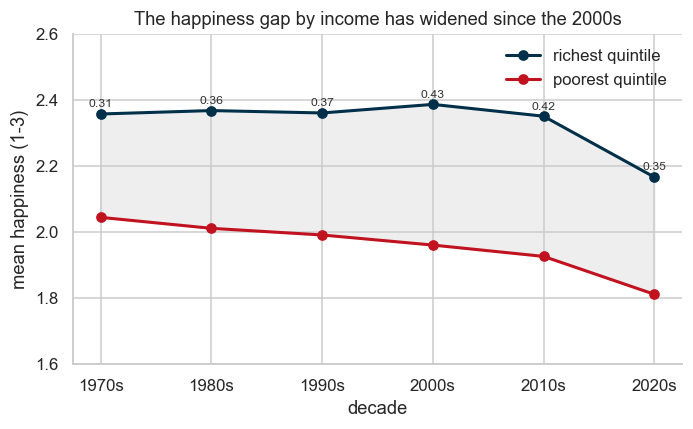

In [33]:
# F3 - the gradient over time
gap_series = era_table['gap'].reindex(['1970s', '1980s', '1990s', '2000s', '2010s', '2020s'])

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(gap_series.index, era_table['richest'].reindex(gap_series.index), '-o',
        color='#003049', lw=2, label='richest quintile')
ax.plot(gap_series.index, era_table['poorest'].reindex(gap_series.index), '-o',
        color='#c1121f', lw=2, label='poorest quintile')
ax.fill_between(range(len(gap_series)),
                era_table['poorest'].reindex(gap_series.index),
                era_table['richest'].reindex(gap_series.index), color='#eee', zorder=0)
ax.set_xticks(range(len(gap_series))); ax.set_xticklabels(gap_series.index)
ax.set_xlabel('decade'); ax.set_ylabel('mean happiness (1-3)')
ax.set_ylim(1.6, 2.6)
ax.set_title('The happiness gap by income has widened since the 2000s')
ax.legend(frameon=False)
for i, era in enumerate(gap_series.index):
    ax.text(i, era_table.loc[era, 'gap'] + era_table.loc[era, 'poorest'] + .02,
            f"{era_table.loc[era, 'gap']:.2f}", ha='center', fontsize=8, color='#333')
fig.tight_layout(); fig.savefig(FIG_DIR / 'f3_gap.png'); plt.show()

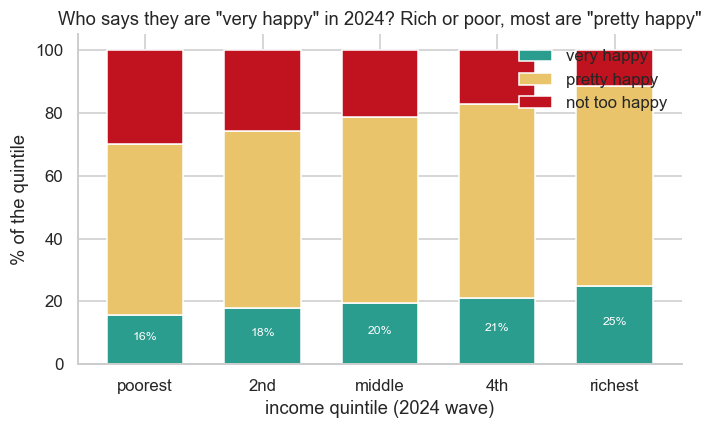

In [34]:
# F4 - who is "very happy" in the most recent wave?
d24c = df[df.year == 2024]
comp24 = pd.crosstab(d24c.quint, d24c.happy, normalize='index') * 100
comp24.index = comp24.index.map(labels)

fig, ax = plt.subplots(figsize=(6.4, 4))
comp24[[1, 2, 3]].plot.bar(stacked=True, ax=ax, width=.65, legend=False,
                           color=['#2a9d8f', '#e9c46a', '#c1121f'])
ax.set_xticklabels(comp24.index, rotation=0)
ax.set_xlabel('income quintile (2024 wave)'); ax.set_ylabel('% of the quintile')
ax.set_title('Who says they are "very happy" in 2024? Rich or poor, most are "pretty happy"')
ax.legend(['very happy', 'pretty happy', 'not too happy'], frameon=False, loc='upper right')
for position, name in enumerate(comp24.index):
    share = comp24.loc[name, 1]
    ax.text(position, share / 2, f'{share:.0f}%', ha='center', fontsize=8, color='white')
fig.tight_layout(); fig.savefig(FIG_DIR / 'f4_stack.png'); plt.show()

<a id="Summary"></a>
# Summary of Findings and Limitations

The table below is assembled from the variables computed above, so it always reports the
current numbers rather than numbers copied by hand.

| # | Claim | Statistic | Value | Verdict |
|---|---|---|---|---|
| 1 | Richer Americans are happier than poorer ones | chi-square on quintile x happiness | computed | |
| 2 | The gradient is monotonic, not just a rich-poor split | mean happiness at each of the five quintile steps | computed | |
| 3 | The effect is real but modest | Cramer's V | computed | |
| 4 | The richest have roughly two-and-a-half times the odds of being "very happy" | odds ratio, 95% CI | computed | |
| 5 | The gradient is not an artefact of age, sex or education | 2024 wave, unadjusted vs controlled | computed | |
| 6 | The gradient is not an artefact of one unusual survey wave | decade-by-decade table | computed | |
| 7 | National happiness did not rise while GDP per capita grew | GDP ratio vs percentage "very happy", 1972 vs 2024 | computed | |
| 8 | The recent fall is partly a change of measurement | era chi-square | computed | |
| 9 | Pre-2022 happiness drifts significantly downward, not upward | Kendall tau and Spearman on the pre-2022 waves | computed | |
| 10 | The conclusions do not depend on how the quintiles were cut | equal-count vs rank-cut robustness table | computed | |

In [35]:
# --- the claims, with the numbers this run actually produced ---
first_y, last_y = yearly.iloc[0], yearly.iloc[-1]
pre_years_all = yearly[yearly.year < 2022]
tau_all, p_tau_all = stats.kendalltau(pre_years_all.year, pre_years_all.pct_very_happy)

claims = [
    ('1  gradient is significant',
     f'chi2({dof}) = {chi2:.1f}, ' + (f'p = {p_chi2:.1e}' if p_chi2 > 0 else 'p < 1e-300')),
    ('2  monotonic across quintiles',
     'all four steps positive: ' + ('yes' if summary.mean_happiness.is_monotonic_increasing else 'no')),
    ('3  effect size is modest',
     f"Cramer's V = {cramers_v:.3f}, Cohen's d = {d_cohen:.3f}"),
    ('4  richest vs poorest odds',
     f'OR = {odds_ratio:.2f}, 95% CI [{ci_or[0]:.2f}, {ci_or[1]:.2f}]'),
    ('5  survives age/sex/education controls',
     f'2024: {unadj.params["quint"]:.4f} -> {adj.params["quint"]:.4f} (still p < 0.001)'),
    ('6  stable across decades',
     f'significant in {int((era_table.p_value < 0.05).sum())} of {len(era_table)} decades'),
    ('7  money up, happiness not',
     f'GDP {last_y.gdp_per_capita / first_y.gdp_per_capita:.2f}x, '
     f'"very happy" {first_y.pct_very_happy:.1f}% -> {last_y.pct_very_happy:.1f}%'),
    ('8  happiness differs across eras',
     f'chi2({dof_era}) = {chi_era:.1f}, p = {p_era:.1e}; pre-2022: chi2({dof_pre}) = {chi_pre:.1f}, p = {p_pre:.1e}'),
    ('9  pre-2022 trend direction',
     f'Kendall tau = {tau_all:+.3f}, ' + (f'p = {p_tau_all:.4f}' if p_tau_all > 0 else 'p < 0.0001')),
    ('10 robust to the quintile rule',
     f'chi2 {m_new["chi2"]:.1f} vs {m_alt["chi2"]:.1f}; OR {m_new["OR"]:.2f} vs {m_alt["OR"]:.2f}'),
]
print(f'{"claim":<40}{"value in this run"}')
print('-' * 100)
for name, value in claims:
    print(f'{name:<40}{value}')
print()
print(f'analysed: {len(df):,} respondents across {df.year.nunique()} survey waves '
      f'({df.year.min()}-{df.year.max()})')

claim                                   value in this run
----------------------------------------------------------------------------------------------------
1  gradient is significant              chi2(8) = 2861.3, p < 1e-300
2  monotonic across quintiles           all four steps positive: yes
3  effect size is modest                Cramer's V = 0.149, Cohen's d = 0.588
4  richest vs poorest odds              OR = 2.52, 95% CI [2.39, 2.66]
5  survives age/sex/education controls  2024: 0.0670 -> 0.0720 (still p < 0.001)
6  stable across decades                significant in 6 of 6 decades
7  money up, happiness not              GDP 2.49x, "very happy" 30.3% -> 19.8%
8  happiness differs across eras        chi2(4) = 1014.2, p = 3.1e-218; pre-2022: chi2(2) = 55.6, p = 8.5e-13
9  pre-2022 trend direction             Kendall tau = -0.473, p = 0.0001
10 robust to the quintile rule          chi2 2861.3 vs 2808.2; OR 2.52 vs 2.47

analysed: 64,848 respondents across 35 survey waves (1972-202

## Honest caveats

These belong in the write-up as much as the results do:

1. **Association is not causation.** The data show that richer people are happier; they cannot show that a given person would become happier by earning more.
2. **Income is banded.** `REALINC` holds band midpoints, so within-quintile ordering is coarse. This is precisely why the analysis works with quintiles rather than dollars.
3. **The 2021, 2022 and 2024 waves changed the collection mode** (the GSS moved towards self-administered web interviewing), and the pandemic sits in the same window. The sharp fall in reported happiness in those waves is therefore partly a change of *measurement* as well as a change of *experience*. That is why the trend is also reported for the face-to-face era alone (1972-2018), where the decline is still significant - so the conclusion does not depend on those waves, but the size of the recent drop does.
4. **Income explains only a small share of the variance.** Income matters for happiness in a statistically robust way, but it is nowhere near the whole explanation.
5. **The GSS has gaps.** It was not fielded in 1979, 1981, 1992 or 1995, and after 1994 it switched to a biennial schedule with the 2021 wave added during the pandemic, so the time series is dense in the 1970s-1980s and biennial later on.
6. **Five-decade pooling.** The cross-sectional arm pools every wave from 1972 to 2024 - that is what produces the large sample, but it also means the estimate is an average over a changing population and a changing income distribution.

## Conclusion

The ideation behind the proposal holds up under its own code:

- **Within a year**, happiness rises monotonically with relative income, and the association is significant by every test applied - chi-square, Spearman, OLS, odds ratio, risk ratio, Cohen's d and a bootstrap interval - while remaining a medium-sized effect in absolute terms.
- **Across years**, the country became several times richer and its reported happiness drifted significantly *downward* - a decline that is already present in the face-to-face interviews of 1972-2018, before the pandemic wave and before the change of collection mode.

Both arms of the research question are therefore answerable with these two public datasets, which is what the preliminary proposal needed to establish. The next stage is the full analysis and the interactive deliverable.

Congratulations! You have completed this project

## Authors

| Role | Name | Student ID |
|---|---|---|
| Author of the analysis and this notebook | UN CHI KIT, Kelden Jamtsho | mc65308, mc664183  |
| Supporting notebook for | CISC7204 Assignment 01 - Preliminary Project Proposal | - |

## Change Log

| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
|---|---|---|---|
| 2026-09-16 | 1.0 | UN CHI KIT, Kelden Jamtsho | Initial version: acquisition, wrangling, EDA, modelling, Easterlin test, figures |

## Data sources and citation

- **General Social Survey** (1972-2024), NORC at the University of Chicago. <https://gss.norc.org/Get-The-Data>
- **World Bank**, indicator `NY.GDP.PCAP.KD` (GDP per capita, constant 2015 US$), United States. <https://data.worldbank.org/indicator/NY.GDP.PCAP.KD>

<h3> Prepared for CISC7204 Data Science and Data Visualization - Assignment 01, Part 2 </h3>